In [1]:
import scienceplots
from matplotlib.ticker import FuncFormatter
import matplotlib as mpl
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import linregress
from scipy.interpolate import interp1d
import matplotlib.cm as cm

warnings.simplefilter(action='ignore')


# Apply default style and parameters
plt.style.use(['nature', 'science'])


#Default parameters for the main figure, using a commonly available sans-serif font
mpl.rcParams.update({
    'lines.linewidth': 2,
    'lines.markersize': 11,  # Added marker size
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'xtick.major.width': 1,
    'ytick.major.width': 1,
    'xtick.labelsize': 40,
    'ytick.labelsize': 40,
    'axes.labelsize': 50,
    'axes.titlesize': 20,
    'axes.linewidth': 1.5,  # Increased linewidth for thicker outlines
    'legend.fontsize': 15,
    'legend.handlelength': 5,
    'legend.handleheight': 1.5,
    'legend.handletextpad': 1.5,
    'legend.labelspacing': 0.4,
    'axes.prop_cycle': plt.cycler(color=['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#d62728', '#8c564b', '#e377c2', '#7f7f7f', '#17becf', '#bcbd22']),
    'text.usetex': False,  # Disable LaTeX text rendering for compatibility
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],  # Use DejaVu Sans or any available sans-serif font
    'figure.figsize': (7, 5)
})

In [2]:
# === Load catalogs ===
props_raw = catalog.load("properties_project_joaco")                # Raw metadata
data_raw = catalog.load("data_project_joaco")                       # Raw I-V data

props_hyst = catalog.load("props_with_maximums_tomas_hysteresis")  # Hysteresis metadata
data_hyst = catalog.load("tomas_hysteresis")       

[05/13/25 11:58:10] INFO     Loading data from properties_project_joaco (CSVDataset)...         ]8;id=595786;file:///Users/mphstph/Documents/GitHub/SnS-Joaquin/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=187271;file:///Users/mphstph/Documents/GitHub/SnS-Joaquin/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#390\390]8;;\

                    INFO     Loading data from data_project_joaco (PartitionedDataset)...       ]8;id=565526;file:///Users/mphstph/Documents/GitHub/SnS-Joaquin/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=126589;file:///Users/mphstph/Documents/GitHub/SnS-Joaquin/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#390\390]8;;\

                    INFO     Loading data from props_with_maximums_tomas_hysteresis             ]8;id=560785;file:///Users/mphstph/Documents/GitHub/SnS-Joaquin/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=786899;file:///Users/mphstph/Documents/GitHub/SnS-Joaquin/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#390\390]8;;\
                             (CSVDataset)...                                                                       

                    INFO     Loading data from tomas_hysteresis (PartitionedDataset)...         ]8;id=755926;file:///Users/mphstph/Documents/GitHub/SnS-Joaquin/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=904513;file:///Users/mphstph/Documents/GitHub/SnS-Joaquin/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#390\390]8;;\

In [3]:
def filter_experiments(df, date_prefix, wavelength, vsd_end=None, info=None):
    query_parts = [f"`Laser wavelength` == {wavelength}"]
    if vsd_end is not None:
        query_parts.append(f"`VSD end` == {vsd_end}")
    if info is not None:
        query_parts.append(f"`Information` == '{info}'")

    query_str = " and ".join(query_parts)

    return (
        df
        .query(query_str)
        .loc[lambda d: d["data_key"].str.startswith(date_prefix)]
        .sort_values("Laser voltage")
        .reset_index(drop=True)
    )


def filter_raw_and_hyst(props_raw, props_hyst, date_prefix, wavelength, info=None, vsd_end=None):
    raw_filtered = filter_experiments(
        df=props_raw,
        date_prefix=date_prefix,
        wavelength=wavelength,
        vsd_end=vsd_end,
        info=info
    )
    hyst_filtered = filter_experiments(
        df=props_hyst,
        date_prefix=date_prefix,
        wavelength=wavelength,
        vsd_end=vsd_end,
        info=info
    )
    return raw_filtered, hyst_filtered

import os

def process_and_plot_all(
    date_prefix, wavelength, info,
    props_raw, props_hyst, data_raw, data_hyst,
    vsd_end=None
):

    # Ensure the figures directory exists
    os.makedirs("figures", exist_ok=True)
    
    # === Plotting logic (unchanged) ===
    def plot_lines_from_filtered(data, data_map, x_col, y_col=None, y_col_getter=None,
                                 title="", y_label="", filename="", marker='o'):
        
    
        n = len(data)
        colors = cm.viridis(np.linspace(0, 1, n))
        fig, ax = plt.subplots(figsize=(15, 15))
        for i, (_, row) in enumerate(data.iterrows()):
            df = data_map[row["data_key"]]()
            if y_col == "I (A)":
                df[y_col] *= 1e6  # Convert to μA

            y_column = y_col_getter(df) if y_col_getter else y_col
            x, y = df[[x_col, y_column]].values.T
            ax.plot(
                x, y,
                label=f'{row["Laser voltage"]:.1f} V',
                color=colors[i],
                marker=marker if marker else None,
                markersize=4 if marker else 0
            )
        ax.set_xlabel("$\\rm V_{DS}$ (V)")
        ax.set_ylabel(y_label)
        ax.set_title(title)
        #ax.legend(title="Laser Voltage (V)", loc="best")
        fig.tight_layout()
        plt.savefig(os.path.join("figures", filename), dpi=300)
        plt.show()

    # === Apply new unified filter ===
    raw_data, hyst_data = filter_raw_and_hyst(
        props_raw=props_raw,
        props_hyst=props_hyst,
        date_prefix=date_prefix,
        wavelength=wavelength,
        info=info,
        vsd_end=vsd_end
    )

    # === Plot raw IV ===
    plot_lines_from_filtered(
        raw_data,
        data_map=data_raw,
        x_col="Vsd (V)",
        y_col="I (A)",
        #title=f"Raw IV - {wavelength} nm",
        y_label="$\\rm I_{{DS}}$ ($\\rm \mu$A)",
        filename=f"IV_{info}_{wavelength}_up.png"
    )

    # === Plot hysteresis ===
    hyst_map = {k: lambda k=k: data_hyst[k]() for k in hyst_data["data_key"]}
    plot_lines_from_filtered(
        hyst_data,
        data_map=hyst_map,
        x_col="Vsd (V)",
        y_col_getter=lambda df: df.columns[1],
        #title=f"Hysteresis - {wavelength} nm",
        y_label="Measured Hysteresis [A]",
        filename=f"hysteresis_{info}_{wavelength}.png",
        marker=None
    )
  


def build_calibration_functions(props_df, data_dict, date_prefix, wavelengths):
    calibration = {}
    for wl in wavelengths:
        filtered = props_df.loc[
            (props_df["Procedure type"] == "LaserCalibration") &
            (props_df["Laser wavelength"] == wl) &
            (props_df["data_key"].str.startswith(date_prefix))
        ]
        if filtered.empty:
            continue

        key = filtered["data_key"].iloc[0]
        df = data_dict[key]() if callable(data_dict[key]) else data_dict[key]
        f = interp1d(df["VL (V)"], df["Power (W)"], kind="linear", fill_value="extrapolate")
        calibration[wl] = f
    return calibration


def apply_calibration(df, voltage_col, wl, calibration_fns, area_factor, new_col="LED power"):
    if wl not in calibration_fns:
        raise ValueError(f"No calibration function found for {wl} nm")
    f = calibration_fns[wl]
    df[new_col] = df[voltage_col].apply(f) * area_factor
    return df

def plot_hyst_vs_power(
    date_prefix:str,
    wavelength:int,
    info:str,
    props_raw, props_hyst, data_raw,
    area_factor:float
):
    # 1) build calibrators
    cals = build_calibration_functions(props_raw, data_raw, date_prefix, [wavelength])

    # 2) filter
    _, hyst = filter_raw_and_hyst(
        props_raw   = props_raw,
        props_hyst  = props_hyst,
        date_prefix = date_prefix,
        wavelength  = wavelength,
        info        = info
    )

    if hyst.empty:
        raise ValueError(
            f"No hysteresis rows for "
            f"{date_prefix}, {wavelength} nm, info={info}"
        )

    # 3) calibrate
    hyst = apply_calibration(
        df              = hyst,
        voltage_col     = "Laser voltage",
        wl              = wavelength,
        calibration_fns = cals,
        area_factor     = area_factor,
        new_col         = "LED power"
    )

    # 4) plot
    fig, ax = plt.subplots(figsize=(8,6))
    ax.plot(
        hyst["LED power"],
        hyst["max_positive_hysteresis"],
        "o-", label="hyst vs power"
    )

    # guard the max‐point
    if not hyst["LED power"].empty:
        idx = hyst["LED power"].idxmax()
        pwr = hyst.at[idx, "LED power"]
        hy  = hyst.at[idx, "max_positive_hysteresis"]
        ax.scatter([pwr], [hy], color="red", zorder=5)
        ax.annotate(
            f"max: {hy:.2e} A\n@ {pwr:.2e} W",
            (pwr, hy),
            textcoords="offset points", xytext=(10,-15)
        )

    ax.set_xlabel("Effective Power [W]")
    ax.set_ylabel("Max Positive Hysteresis [A]")
    ax.set_title(f"{wavelength} nm")
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"hysteresis_vs_power_{wavelength}nm.png", dpi=300)
    plt.show()



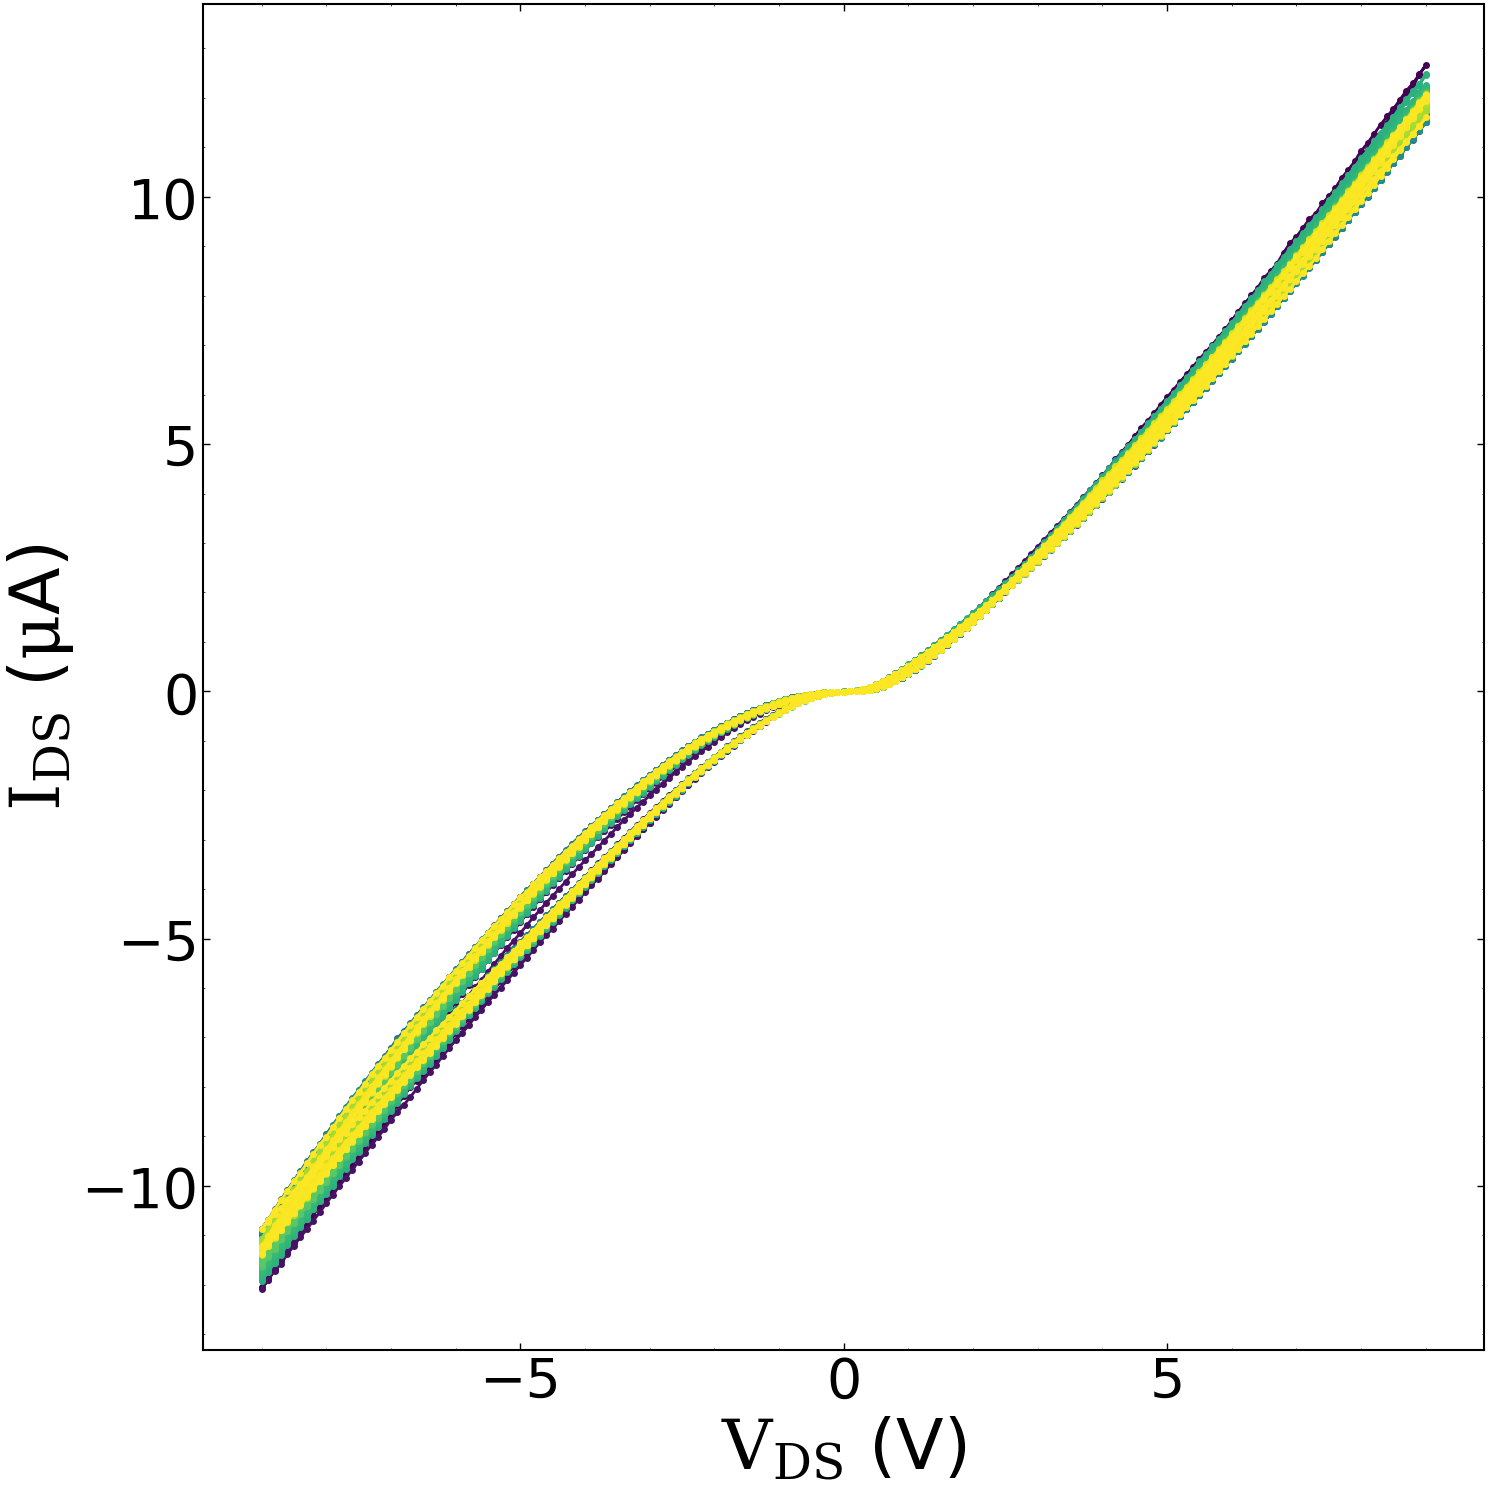

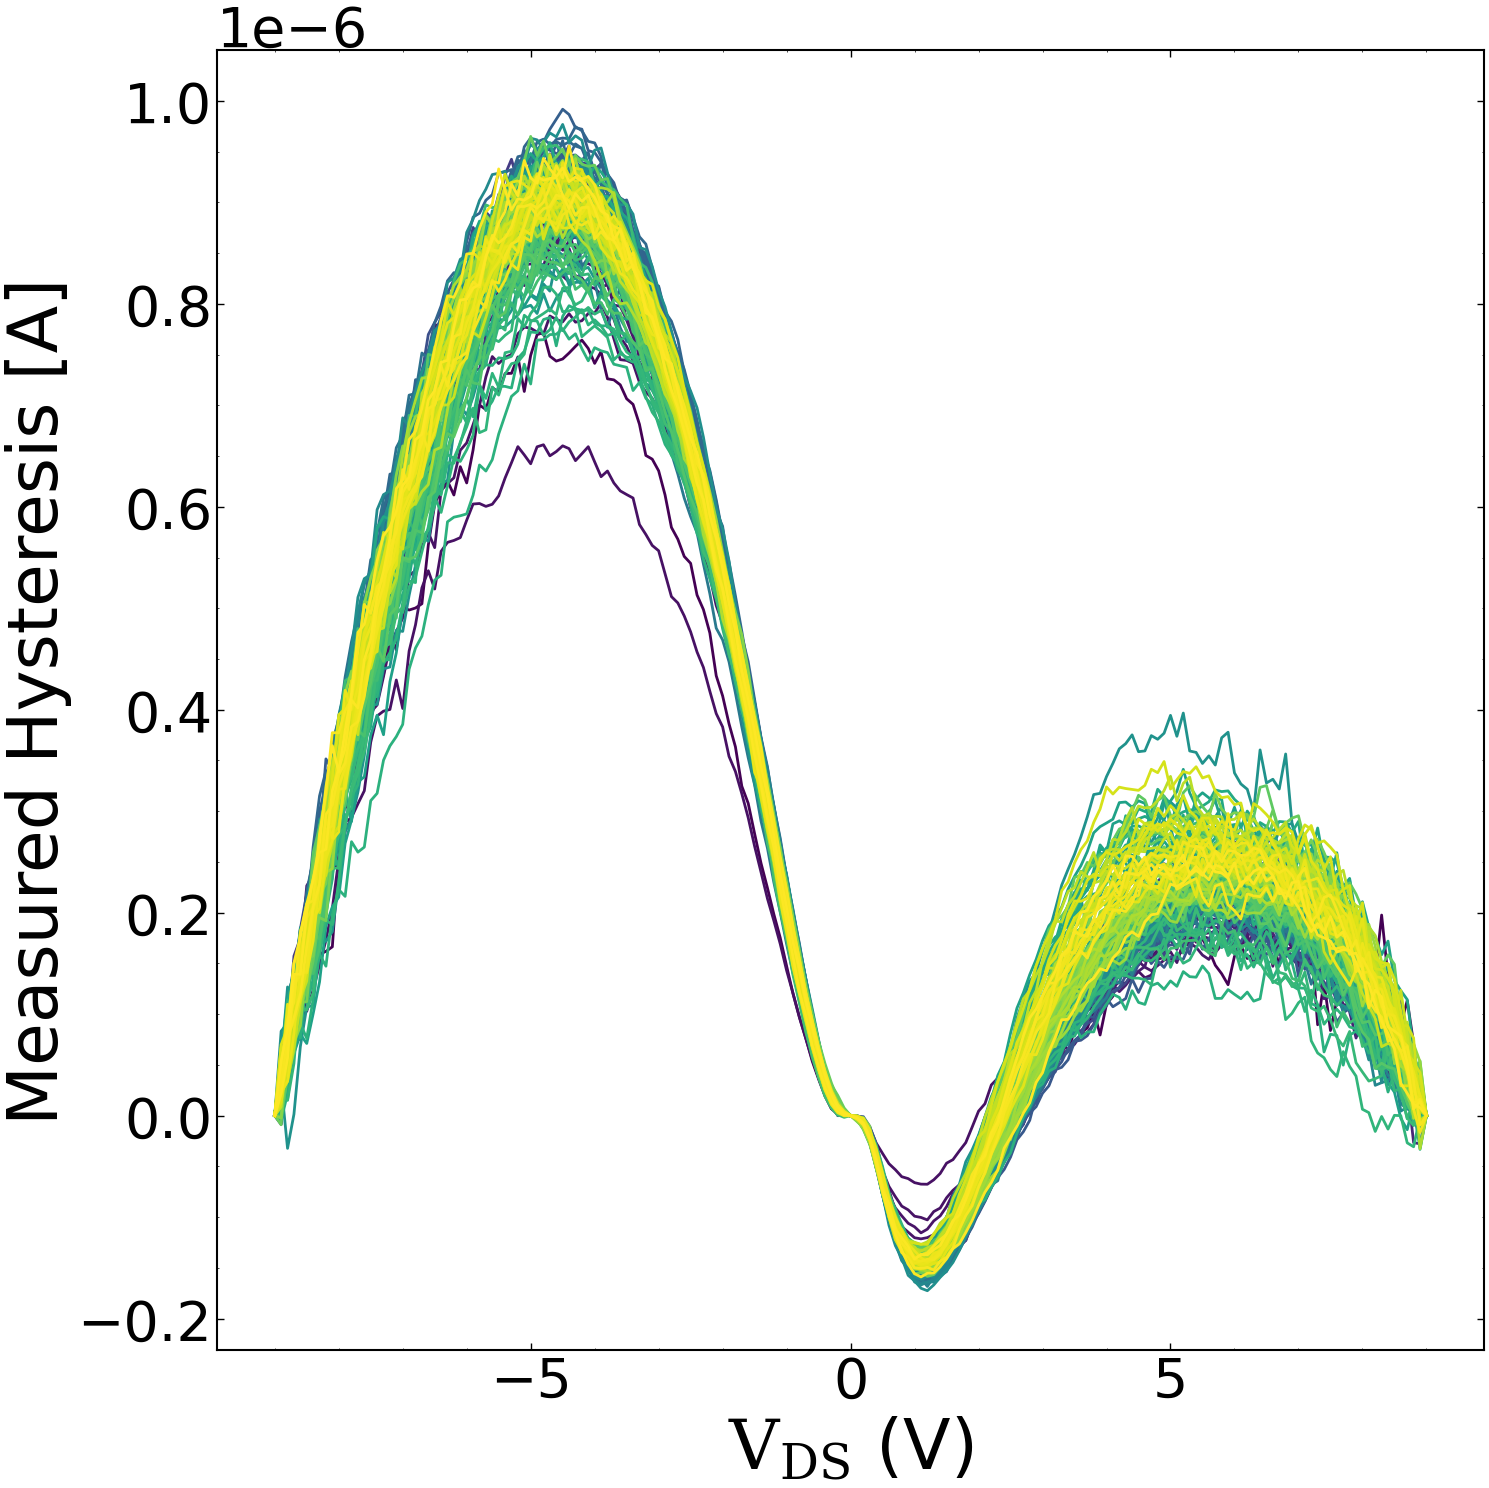

In [4]:
process_and_plot_all(
    date_prefix="2025-05-06",
    wavelength=0,
    info="SnS - Stability",
    props_raw=props_raw,
    props_hyst=props_hyst,
    data_raw=data_raw,
    data_hyst=data_hyst
)

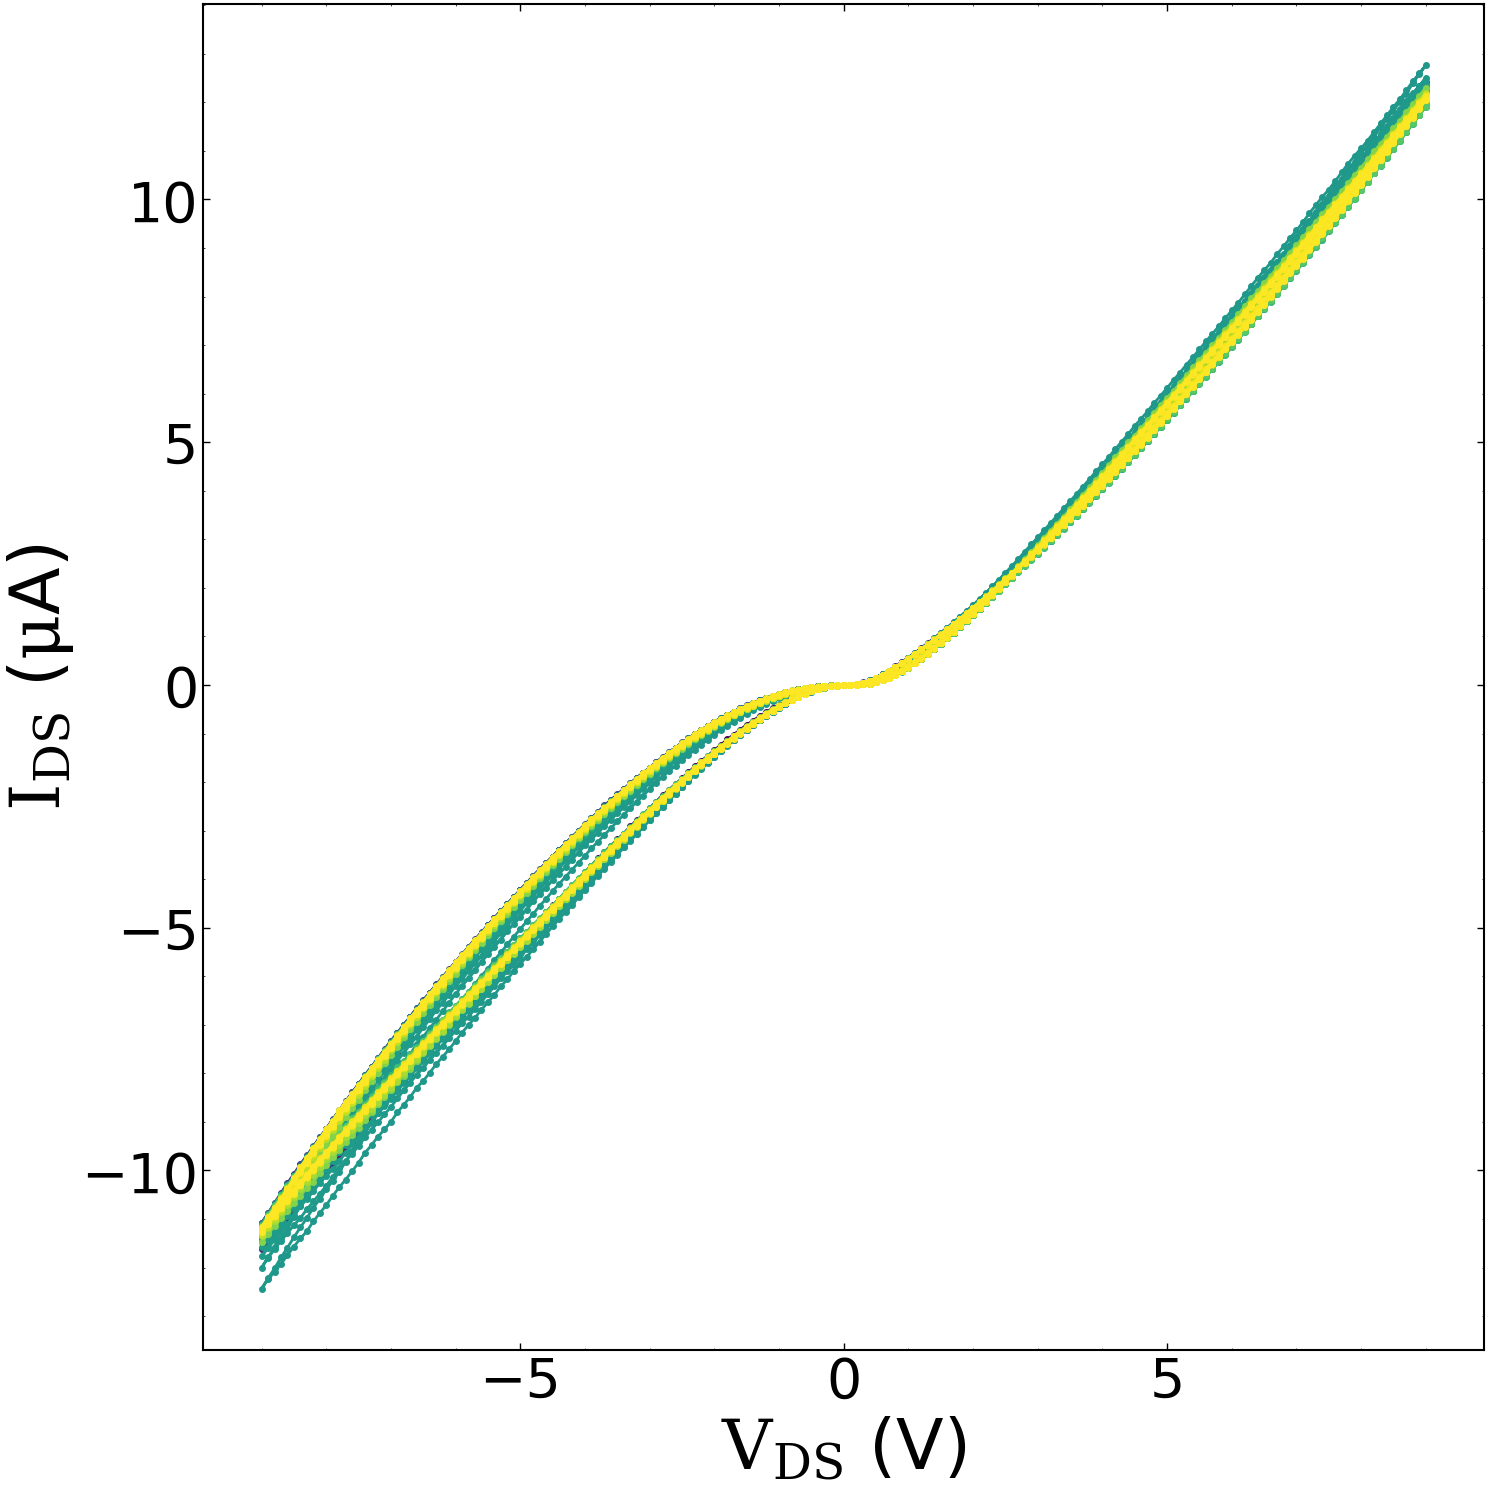

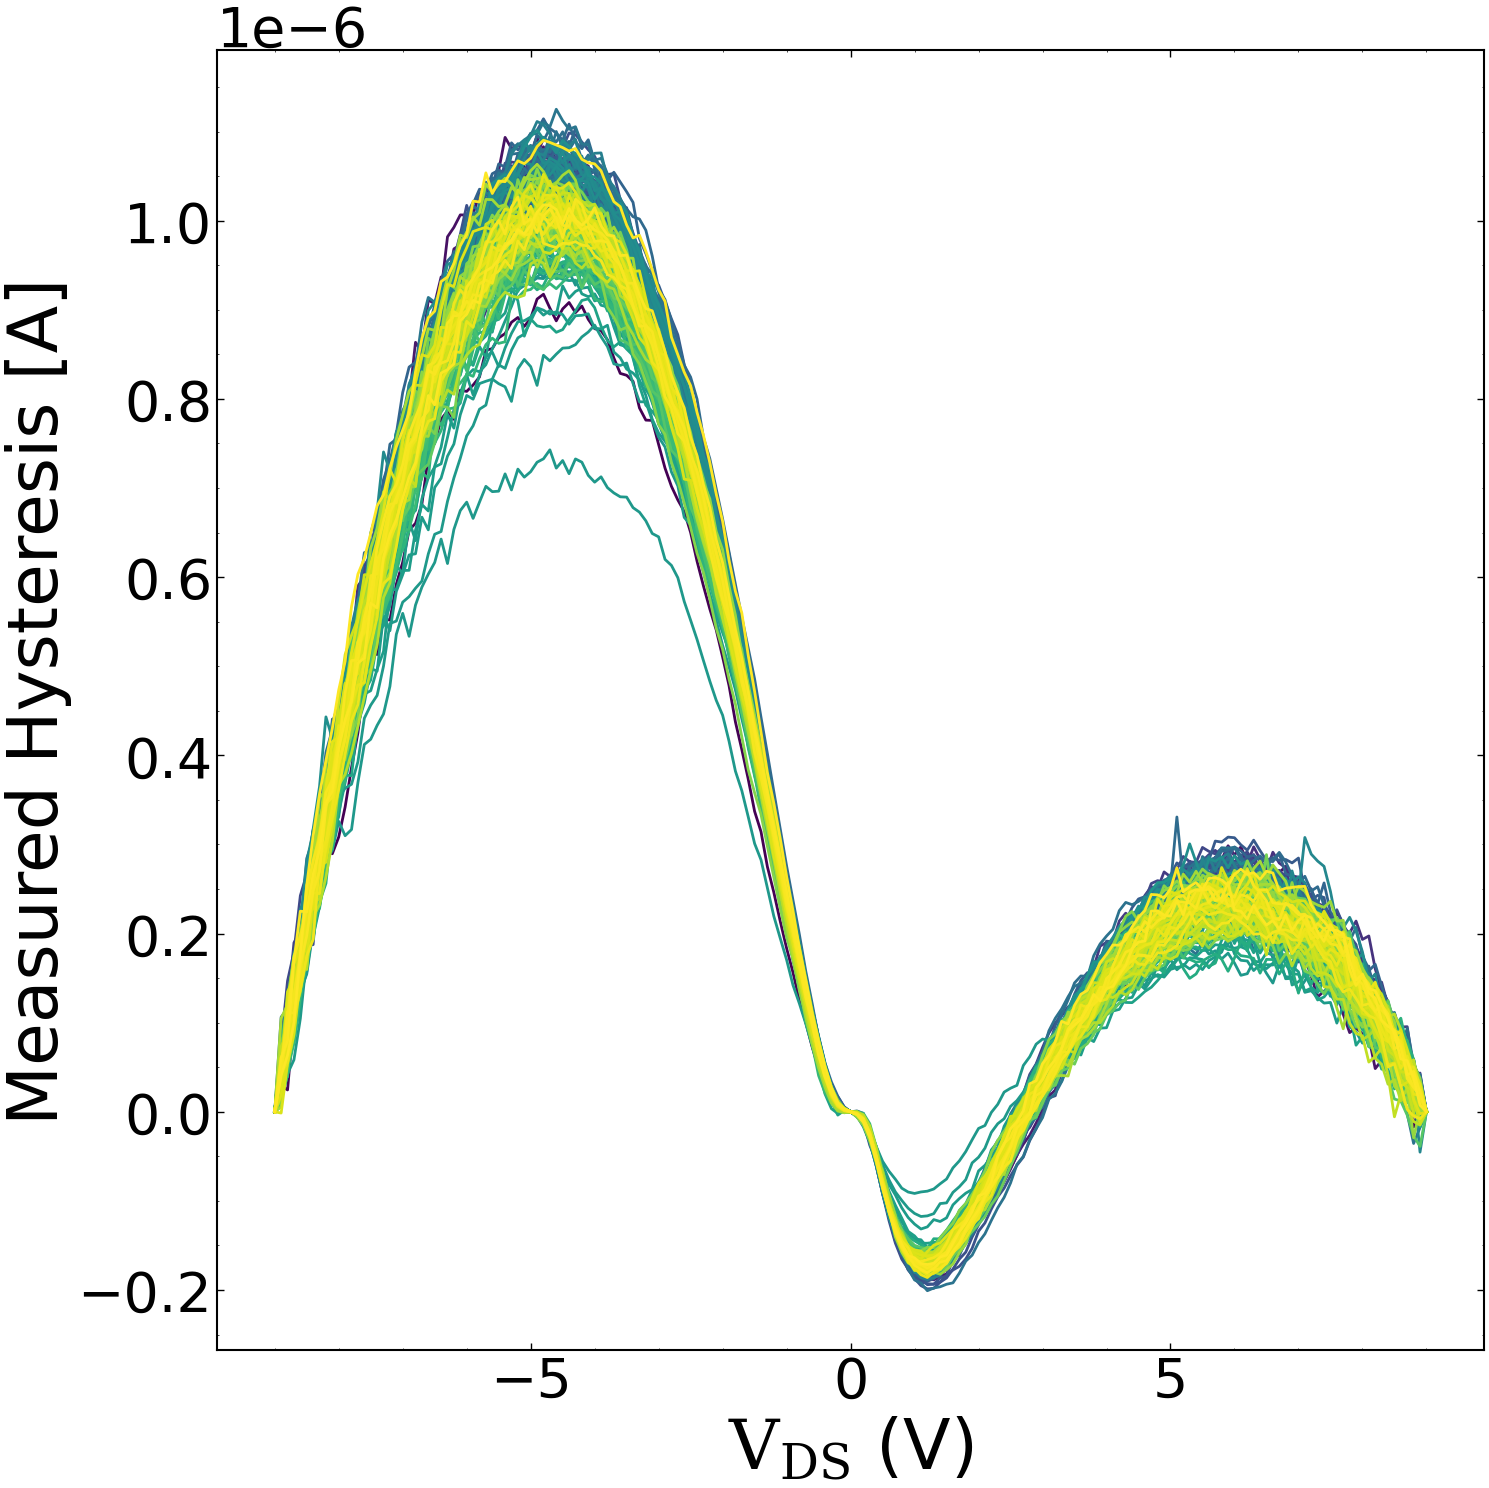

In [5]:
process_and_plot_all(
    date_prefix="2025-05-06",
    wavelength=0,
    info="SnS - Stability - white light",
    props_raw=props_raw,
    props_hyst=props_hyst,
    data_raw=data_raw,
    data_hyst=data_hyst
)

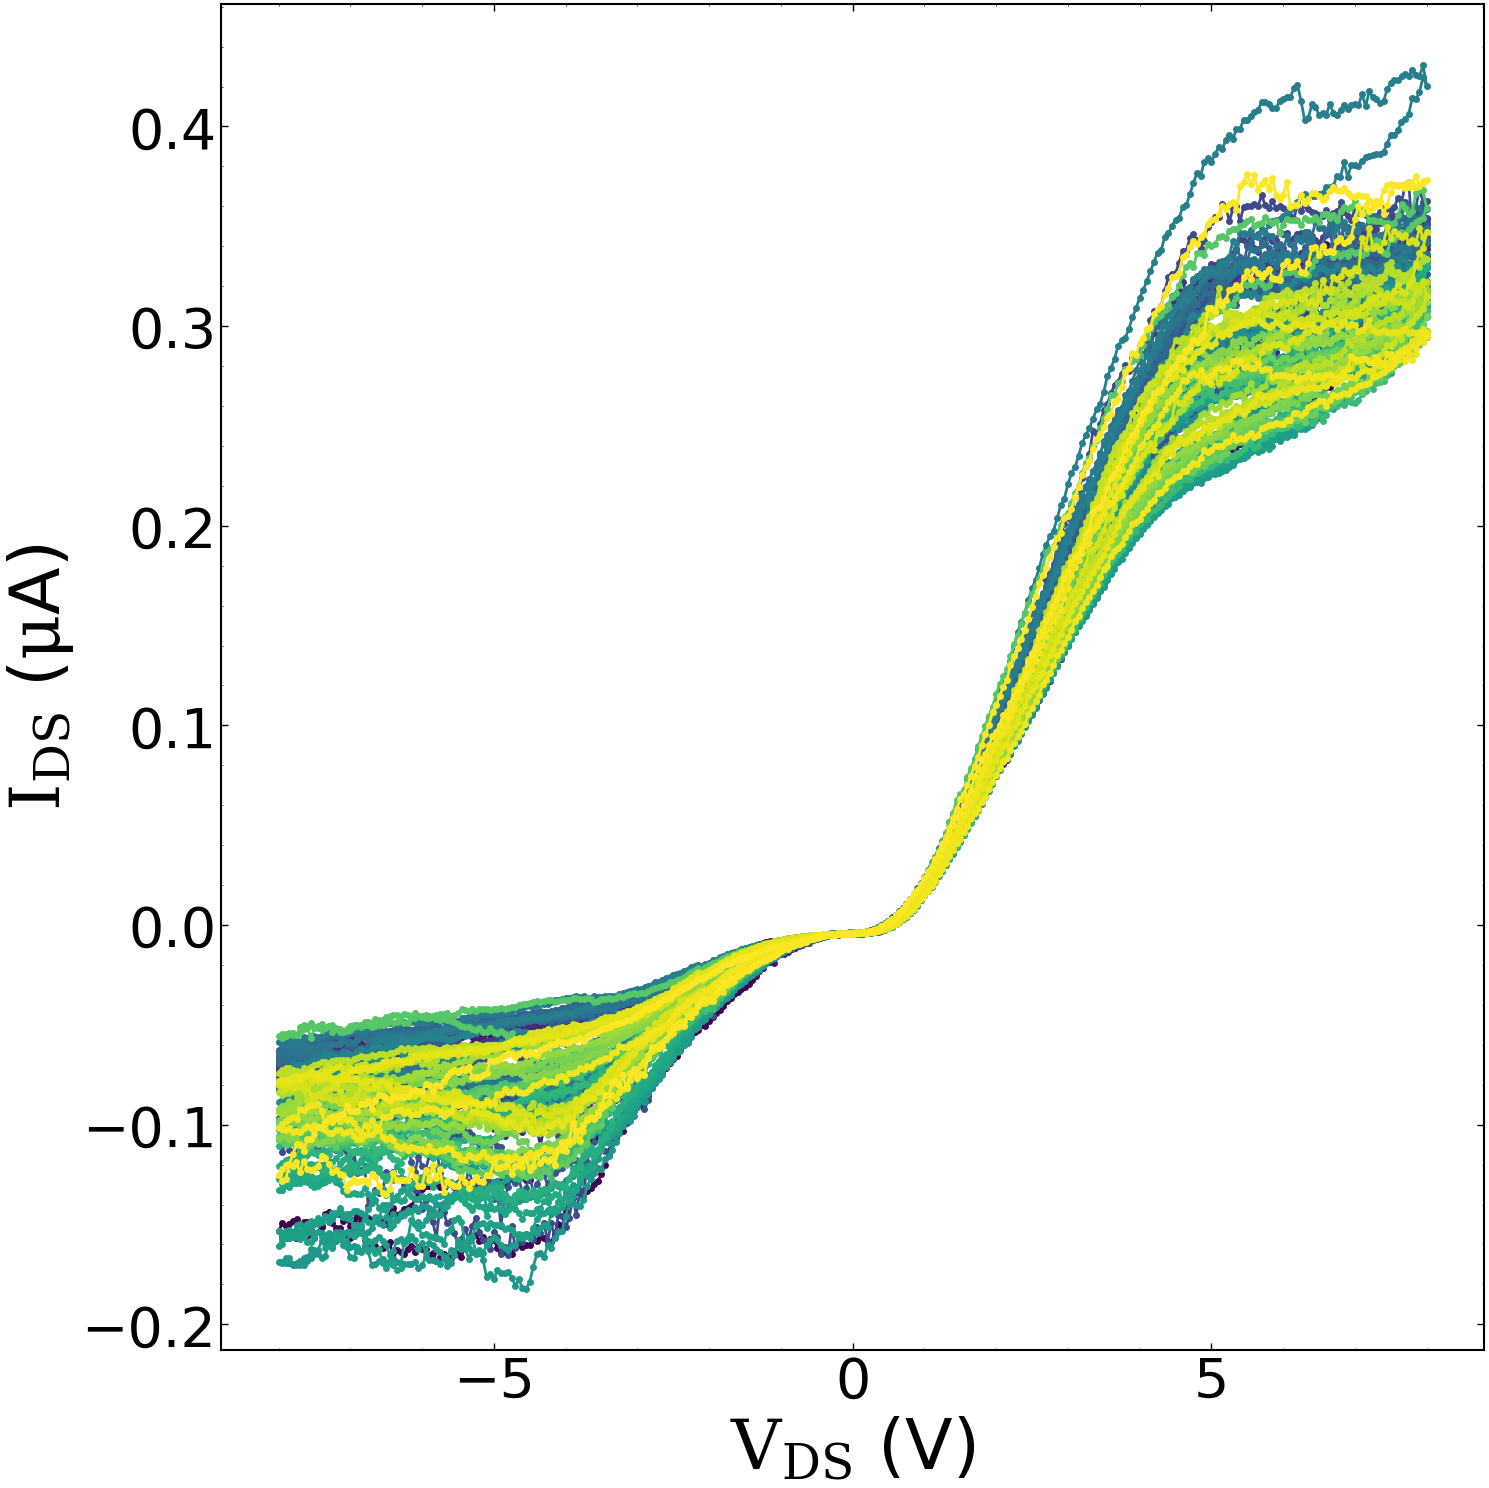

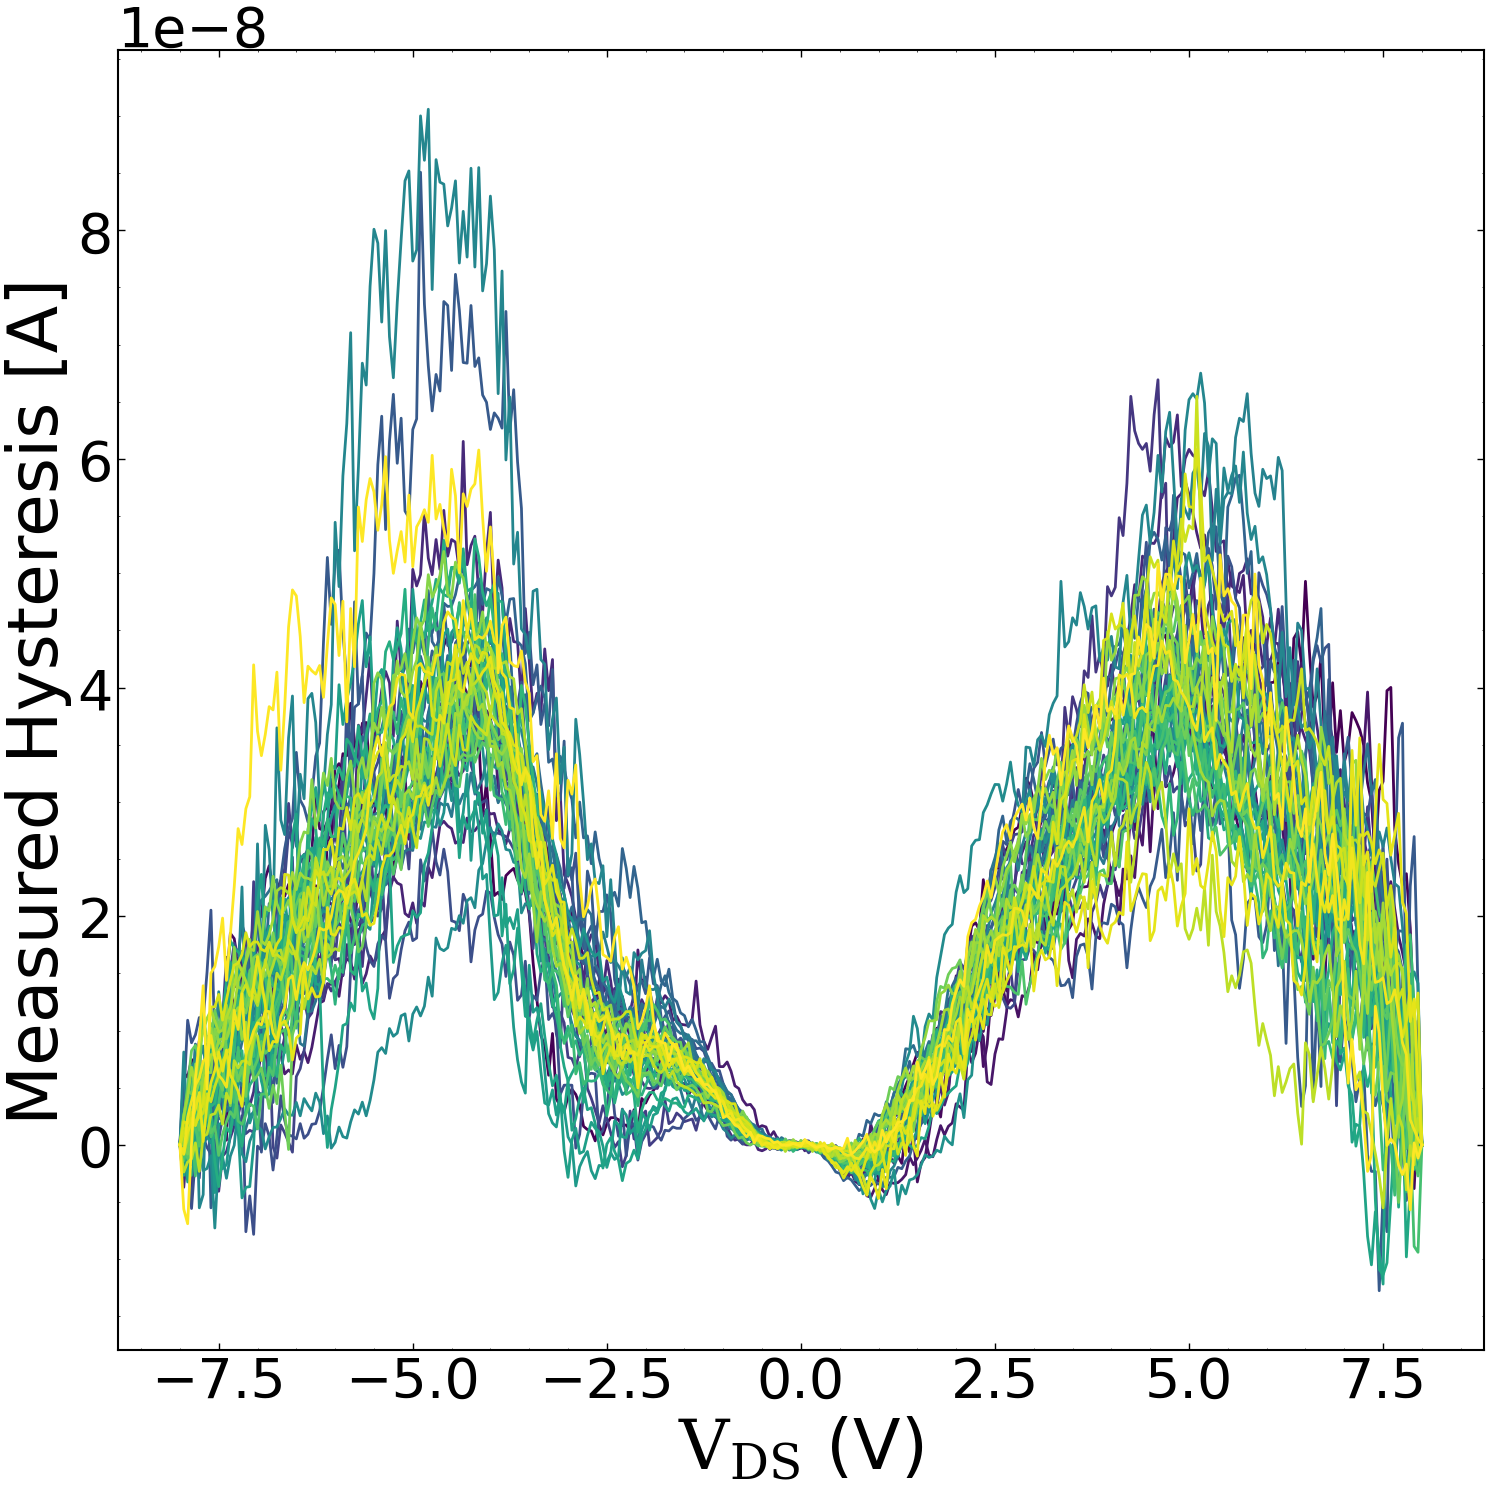

In [6]:
process_and_plot_all(
    date_prefix="2025-04-16",
    wavelength=0,
    info="SnS - 10 um - No Light - 10 times",
    props_raw=props_raw,
    props_hyst=props_hyst,
    data_raw=data_raw,
    data_hyst=data_hyst
)

In [7]:
mpl.rcParams.update({
    'lines.linewidth': 2,
    'lines.markersize': 11,  # Added marker size
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'xtick.major.width': 1,
    'ytick.major.width': 1,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'axes.labelsize': 20,
    'axes.titlesize': 20,
    'axes.linewidth': 1.5,  # Increased linewidth for thicker outlines
    'legend.fontsize': 15,
    'legend.handlelength': 5,
    'legend.handleheight': 1.5,
    'legend.handletextpad': 1.5,
    'legend.labelspacing': 0.4,
    'axes.prop_cycle': plt.cycler(color=['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#d62728', '#8c564b', '#e377c2', '#7f7f7f', '#17becf', '#bcbd22']),
    'text.usetex': False,  # Disable LaTeX text rendering for compatibility
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],  # Use DejaVu Sans or any available sans-serif font
    'figure.figsize': (7, 5)
})

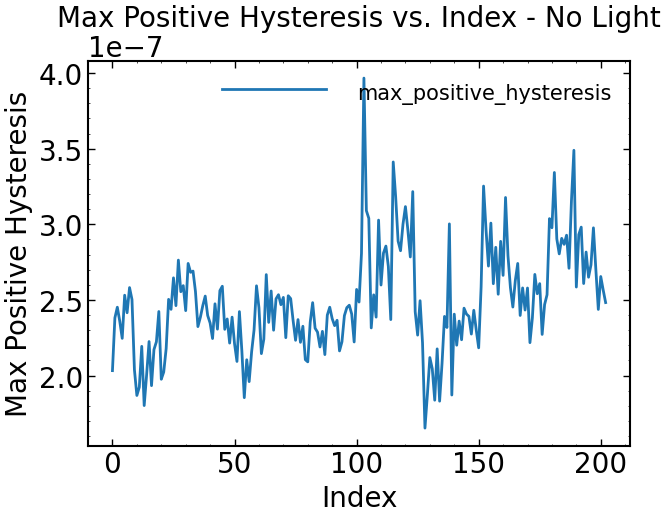

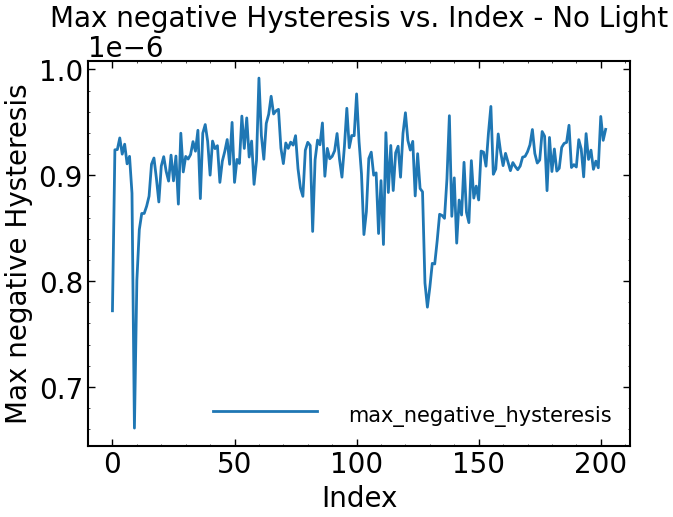

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

In [13]:
hyst_no_light = filter_experiments(
    df=props_hyst,
    date_prefix="2025-05-06",
    wavelength=0,
    info="SnS - Stability"
)


hyst_no_light.plot(
    y="max_positive_hysteresis",
    title="Max Positive Hysteresis vs. Index - No Light",
    ylabel="Max Positive Hysteresis",
    xlabel="Index"
)


hyst_no_light.plot(
    y="max_negative_hysteresis",
    title="Max negative Hysteresis vs. Index - No Light",
    ylabel="Max negative Hysteresis",
    xlabel="Index"
)


# 1) Positive hysteresis
ax = hyst_no_light.plot(
    y="max_positive_hysteresis",
    title="Max Positive Hysteresis vs. Index - No Light",
    ylabel="Max Positive Hysteresis",
    xlabel="Index"
)
fig = ax.get_figure()
fig.savefig(
    "max_positive_hysteresis_no_light.png",
    dpi=300,
    bbox_inches="tight"
)
plt.clf()  # clear the figure for the next plot

# 2) Negative hysteresis
ax = hyst_no_light.plot(
    y="max_negative_hysteresis",
    title="Max Negative Hysteresis vs. Index - No Light",
    ylabel="Max Negative Hysteresis",
    xlabel="Index"
)
fig = ax.get_figure()
fig.savefig(
    "max_negative_hysteresis_no_light.png",
    dpi=300,
    bbox_inches="tight"
)
plt.clf()

<Axes: title={'center': 'Max negative Hysteresis vs. Index - White Light'}, xlabel='Index', ylabel='Max negative Hysteresis'>

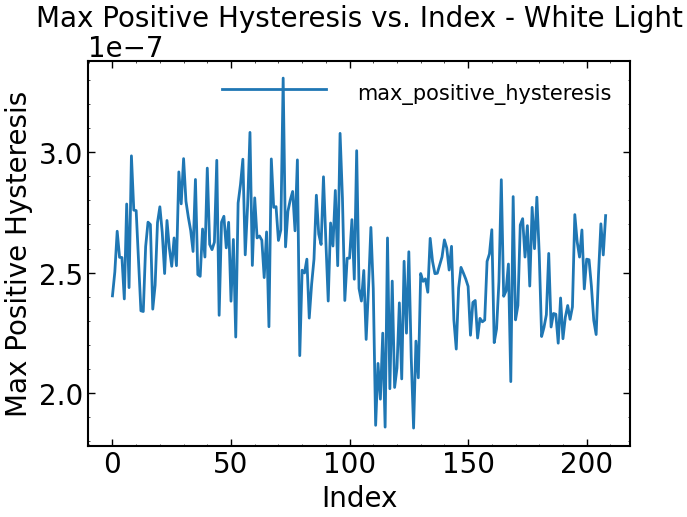

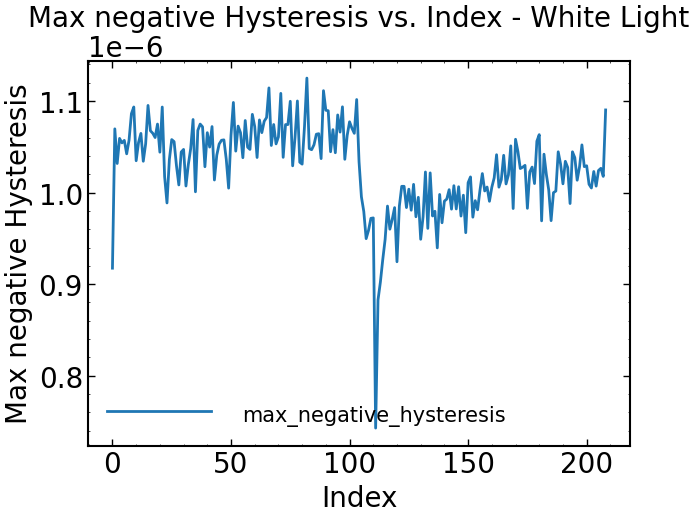

In [14]:


hyst_white_light = filter_experiments(
    df=props_hyst,
    date_prefix="2025-05-06",
    wavelength=0,
    info="SnS - Stability - white light"
)


hyst_white_light.plot(
    y="max_positive_hysteresis",
    title="Max Positive Hysteresis vs. Index - White Light",
    ylabel="Max Positive Hysteresis",
    xlabel="Index"
)


hyst_white_light.plot(
    y="max_negative_hysteresis",
    title="Max negative Hysteresis vs. Index - White Light",
    ylabel="Max negative Hysteresis",
    xlabel="Index"
)


In [15]:

# 1) Positive hysteresis
ax = hyst_white_light.plot(
    y="max_positive_hysteresis",
    title="Max Positive Hysteresis vs. Index - White Light",
    ylabel="Max Positive Hysteresis",
    xlabel="Index"
)
fig = ax.get_figure()
fig.savefig(
    "max_positive_hysteresis_white_light.png",
    dpi=300,
    bbox_inches="tight"
)
plt.clf()  # clear the figure for the next plot

# 2) Negative hysteresis
ax = hyst_white_light.plot(
    y="max_negative_hysteresis",
    title="Max Negative Hysteresis vs. Index - White Light",
    ylabel="Max Negative Hysteresis",
    xlabel="Index"
)
fig = ax.get_figure()
fig.savefig(
    "max_negative_hysteresis_white_light.png",
    dpi=300,
    bbox_inches="tight"
)
plt.clf()

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

In [16]:
hyst_april_16 = filter_experiments(
    df=props_hyst,
    date_prefix="2025-04-16",
    wavelength=0,
    info="SnS - 10 um - No Light - 10 times"
)


<Axes: title={'center': 'Max negative Hysteresis vs. Index - No Light'}, xlabel='Index', ylabel='Max negative Hysteresis'>

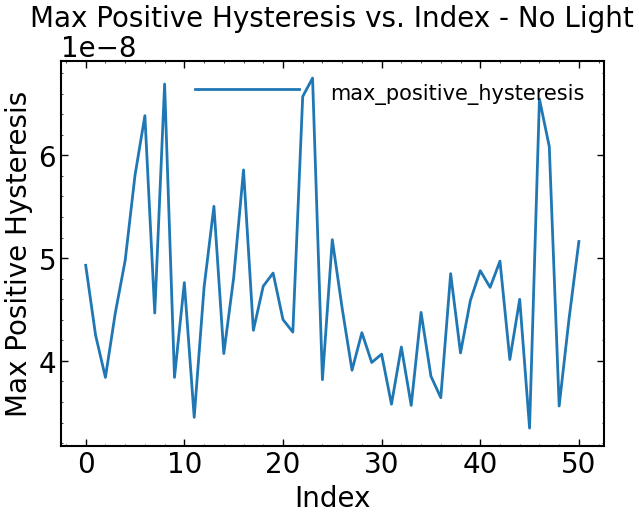

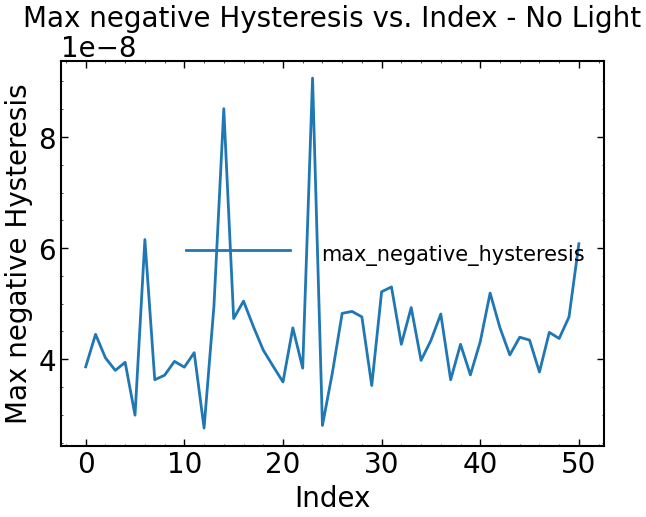

In [17]:
hyst_april_16.plot(
    y="max_positive_hysteresis",
    title="Max Positive Hysteresis vs. Index - No Light",
    ylabel="Max Positive Hysteresis",
    xlabel="Index"
)


hyst_april_16.plot(
    y="max_negative_hysteresis",
    title="Max negative Hysteresis vs. Index - No Light",
    ylabel="Max negative Hysteresis",
    xlabel="Index"
)

In [18]:

# 1) Positive hysteresis
ax = hyst_april_16.plot(
    y="max_positive_hysteresis",
    title="Max Positive Hysteresis vs. Index - No Light",
    ylabel="Max Positive Hysteresis",
    xlabel="Index"
)
fig = ax.get_figure()
fig.savefig(
    "max_positive_hysteresis_10um_no_light.png",
    dpi=300,
    bbox_inches="tight"
)
plt.clf()  # clear the figure for the next plot

# 2) Negative hysteresis
ax = hyst_april_16.plot(
    y="max_negative_hysteresis",
    title="Max Negative Hysteresis vs. Index - No Light",
    ylabel="Max Negative Hysteresis",
    xlabel="Index"
)
fig = ax.get_figure()
fig.savefig(
    "max_negative_hysteresis_10um_no_light.png",
    dpi=300,
    bbox_inches="tight"
)
plt.clf()

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>